In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

## Pandas Analysis

In [6]:
df=pd.read_csv(r'D:\DataSets\Coffe_sales.csv',parse_dates=['Date'],dayfirst=True)
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [12]:
print("Detailed Information of the Dataset:\n")
print(df.info())

Detailed Information of the Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB
None


In [15]:
print('Missing values in the dataset')
print(df.isnull().sum())
print('\nNote:No missing values')

Missing values in the dataset
hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

Note:No missing values


In [25]:
print('Names of the coffee:')
for index,i in enumerate(df['coffee_name'].unique()):
    print(f"{index+1}.{i}")

Names of the coffee:
1.Latte
2.Hot Chocolate
3.Americano
4.Americano with Milk
5.Cocoa
6.Cortado
7.Espresso
8.Cappuccino


In [26]:
# Change date column to date formated column
df['Date']=pd.to_datetime(df['Date'])

In [27]:
ordered=['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
df['Weekday']=pd.Categorical(df['Weekday'],categories=ordered,ordered=True)

In [29]:
Total_sales=df.groupby('coffee_name')['money'].sum().sort_values(ascending=False).reset_index()
print("Top Coffee Type & Size Combination:\n", Total_sales.iloc[0])

Top Coffee Type & Size Combination:
 coffee_name      Latte
money          26875.3
Name: 0, dtype: object


## SQL Analysis

In [28]:
import sqlite3

In [32]:
# Connecting to sql database
conn = sqlite3.connect("coffee_sales.db")
df.to_sql("coffee_sales", conn, if_exists="replace", index=False)


3547

In [36]:
# Total sales by each coffee type.
query='''Select coffee_name,round(sum(money)) as Total_Sales
         from coffee_sales
         group by coffee_name
         order by Total_Sales desc
         '''
pd.read_sql_query(query,conn)

,coffee_name,Total_Sales
0,Latte,26875.0
1,Americano with Milk,24751.0
2,Cappuccino,17439.0
3,Americano,14650.0
4,Hot Chocolate,9933.0
5,Cocoa,8521.0
6,Cortado,7385.0
7,Espresso,2690.0


In [34]:
# total sales by month
query='''Select month_name,sum(money) as Total_Sales
         from coffee_sales
         group by month_name
         '''
pd.read_sql_query(query,conn)

,Month_name,Total_Sales
0,Apr,5719.56
1,Aug,7613.84
2,Dec,8237.74
3,Feb,13215.48
4,Jan,6398.86
5,Jul,6915.94
6,Jun,7617.76
7,Mar,15891.64
8,May,8164.42
9,Nov,8590.54


## Exploratory Data Analysis (EDA)

Top 5 selling products

In [37]:
Total_sales=df['money'].sum()
Average_sales=df['money'].mean()
Top_5_Selling=df.groupby('coffee_name')['money'].sum().sort_values(ascending=False).head(5)

print(f'Total Sales:${Total_sales:.2f}')
print(f'Average Sales:${Average_sales:.2f}')
print(f'\nTop 5 Selling Products:\n{Top_5_Selling}')

Total Sales:$112245.58
Average Sales:$31.65

Top 5 Selling Products:
coffee_name
Latte                  26875.30
Americano with Milk    24751.12
Cappuccino             17439.14
Americano              14650.26
Hot Chocolate           9933.46
Name: money, dtype: float64


Sales Trend by month

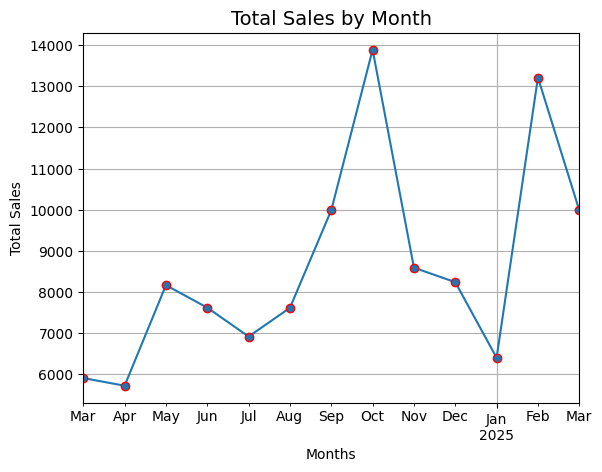


Notes:In 2024 March and April contributes very low sales initially.In May reached high sales again down in month of June and July continously.After June got peak sales in October then got again low.In 2025 Febrary reached highest sales.


In [43]:
Daily_Sales=df.groupby('Date')['money'].sum()
Week_sales=df.resample("W", on="Date")['money'].sum()
Month_sales=df.resample("ME", on="Date")['money'].sum()

Month_sales.plot(kind='line',marker='o',markeredgecolor='red')
plt.grid()
plt.title('Total Sales by Month',fontsize=14)
plt.xlabel('Months')
plt.ylabel('Total Sales')
plt.show()

print('\nNotes:In 2024 March and April contributes very low sales initially.In May reached high sales again down in month of June and July continously.After June got peak sales in October then got again low.In 2025 Febrary reached highest sales.')

Sales Trend by weekdays

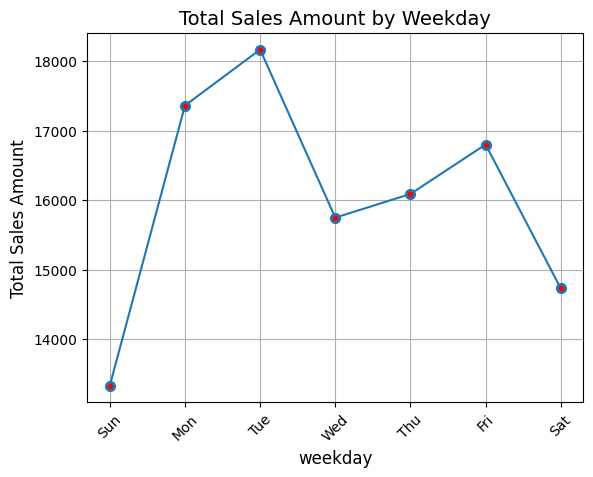


Notes:Weekend(Sunday and Saturday) contributing lowest sales.Weekdays(Monday,Tuesday,Wednesday,Thursday,Friday) contributing highest sales because weekdays are working so sales got high even Tuesday reached highest.


In [53]:
df.groupby('Weekday',observed=True)['money'].sum().plot(marker='o',markerfacecolor='red',markeredgewidth=2)
plt.xticks(rotation=45)
plt.title("Total Sales Amount by Weekday",fontsize=14)
plt.xlabel('weekday',fontsize=12)
plt.ylabel('Total Sales Amount',fontsize=12)
plt.grid()
plt.show()

print('\nNotes:Weekend(Sunday and Saturday) contributing lowest sales.Weekdays(Monday,Tuesday,Wednesday,Thursday,Friday) contributing highest sales because weekdays are working so sales got high even Tuesday reached highest.')

Total sales trend by product Name.

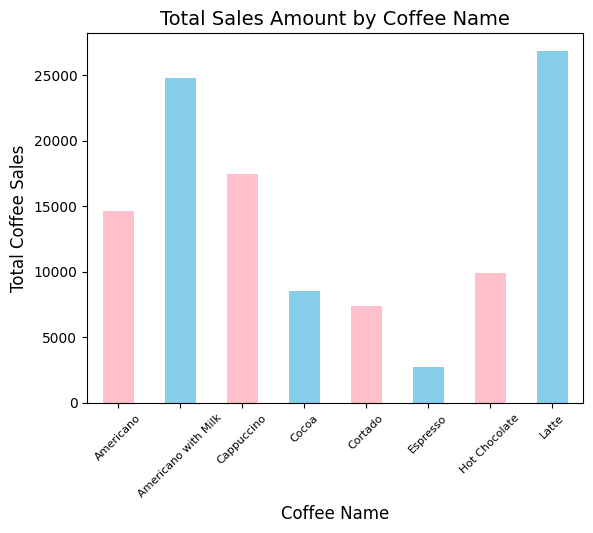


Notes: Total product sales from 2024 to 2025.Highest sales in products are Latte and Americano with milk


In [61]:
df.groupby('coffee_name',)['money'].sum().plot(kind='bar',color=['pink','skyblue'])
plt.xticks(rotation=45,fontsize=8)
plt.title("Total Sales Amount by Coffee Name",fontsize=14)
plt.xlabel('Coffee Name',fontsize=12)
plt.ylabel('Total Coffee Sales',fontsize=12)
plt.show()

print("\nNotes: Total product sales from 2024 to 2025.Highest sales in products are Latte and Americano with milk")

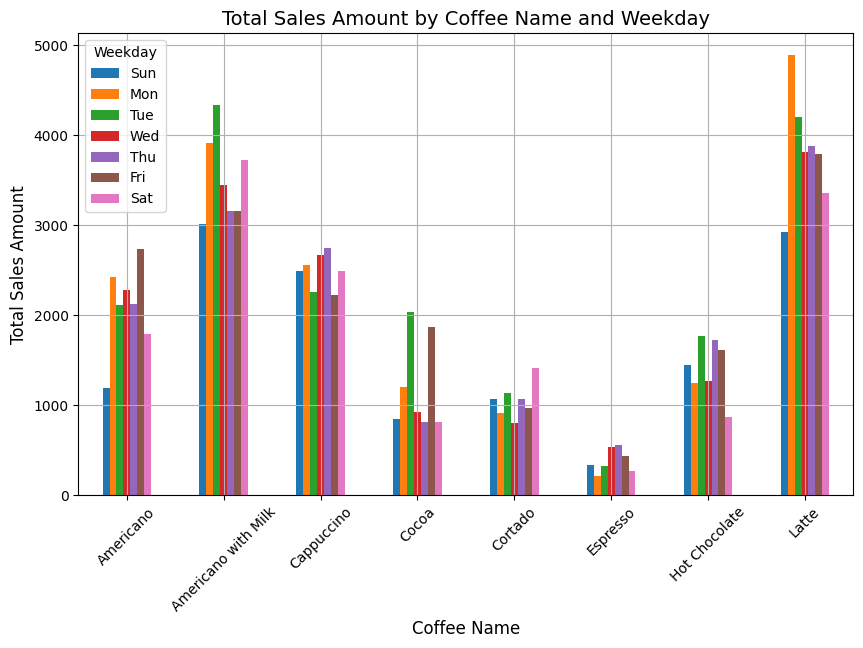


Notes:Latte consistently drives the highest sales throughout the week, especially on Mondays and Tuesdays. In contrast, Espresso and Hot Chocolate record the lowest sales, suggesting an opportunity for promotional offers to boost their demand.


In [67]:
df.groupby(['coffee_name','Weekday'],observed=True)['money'].sum().unstack().plot(kind='bar',figsize=(10,6))
plt.title('Total Sales Amount by Coffee Name and Weekday',fontsize=14)
plt.xlabel('Coffee Name',fontsize=12)
plt.ylabel('Total Sales Amount',fontsize=12)
plt.xticks(rotation=45,fontsize=10)
plt.grid()
plt.show()

print('\nNotes:Latte consistently drives the highest sales throughout the week, especially on Mondays and Tuesdays. In contrast, Espresso and Hot Chocolate record the lowest sales, suggesting an opportunity for promotional offers to boost their demand.')

Sales Trend over by days and weekdays

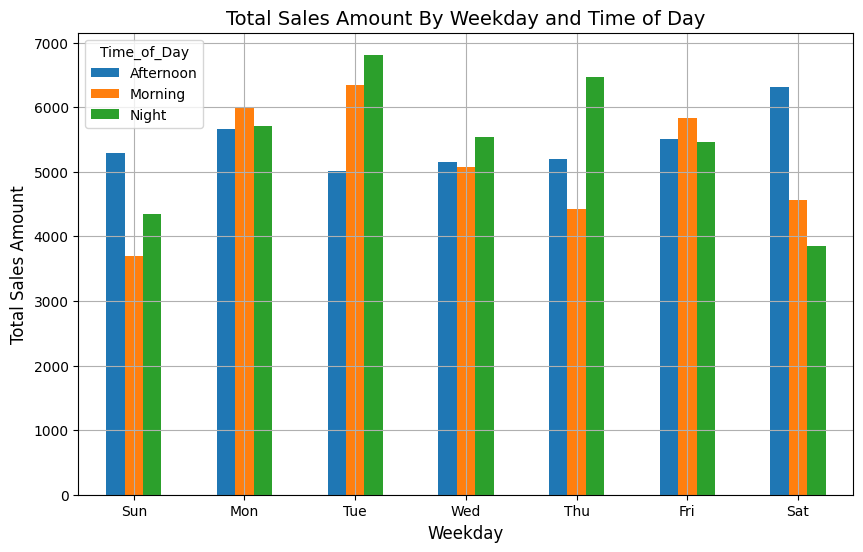


Notes: Most of sales drives towards Morning and Night.In contrast Aftersales peak in weekend.


In [68]:
df.groupby(['Weekday','Time_of_Day'],observed=True)['money'].sum().unstack().plot(kind='bar',figsize=(10,6))
plt.title('Total Sales Amount By Weekday and Time of Day',fontsize=14)
plt.xlabel('Weekday',fontsize=12)
plt.ylabel('Total Sales Amount',fontsize=12)
plt.xticks(rotation=0,fontsize=10)
plt.grid()
plt.show()

print('\nNotes: Most of sales drives towards Morning and Night.In contrast Aftersales peak in weekend.')

Sales Trend by working hours

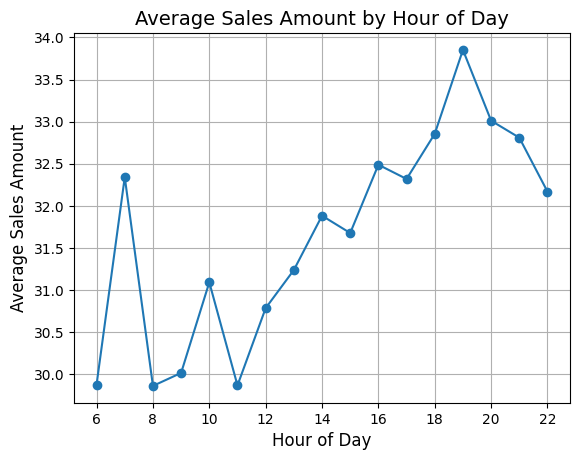


Notes: Morning(7Am) and Evening(6-7Pm) records highest sales because daily commute and relaxing time.While mid-Afternoon hours are slow steady but moderate sales.


In [70]:
df.groupby(['hour_of_day'])['money'].mean().plot(kind='line',marker='o')
plt.title('Average Sales Amount by Hour of Day',fontsize=14)
plt.xlabel('Hour of Day',fontsize=12)
plt.ylabel('Average Sales Amount',fontsize=12)
plt.grid()
plt.show()

print("\nNotes: Morning(7Am) and Evening(6-7Pm) records highest sales because daily commute and relaxing time.While mid-Afternoon hours are slow steady but moderate sales.")

Sales share by coffee type

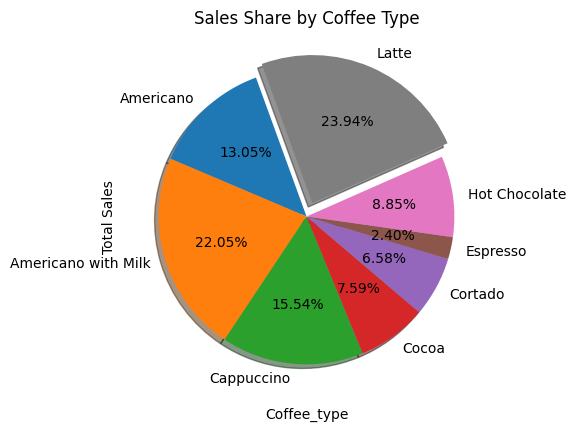

In [71]:
df.groupby('coffee_name')['money'].sum().plot(kind='pie',explode=(0,0,0,0,0,0,0,0.1),shadow=True,startangle=110,autopct="%1.2f%%",radius=1)
plt.xticks(rotation=90)
plt.yticks(rotation=1)
plt.title('Sales Share by Coffee Type')
plt.xlabel('Coffee_type')
plt.ylabel('Total Sales')
plt.show()

Sales Trend over by month

<Axes: xlabel='Month_name'>

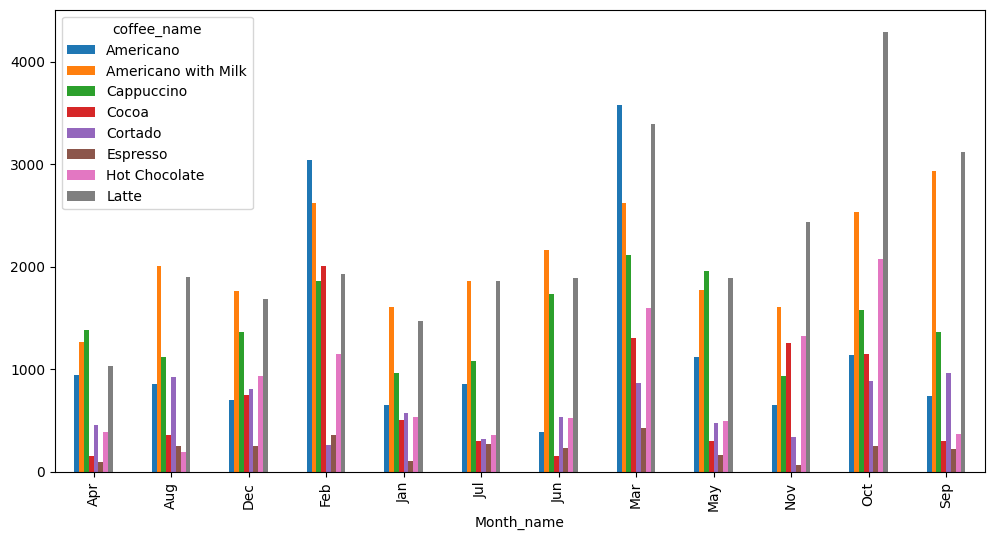

In [73]:
df.groupby(['Month_name','coffee_name'])['money'].sum().unstack().plot(kind='bar',figsize=(12,6))